In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from sklearn.metrics import confusion_matrix



In [29]:
x=pd.read_pickle('../data/processed/features.pkl')
y=pd.read_pickle('../data/processed/target.pkl')
df = pd.read_pickle('../data/processed/cleaned_data.pkl')
df_raw = pd.read_csv('../data/raw/Dataset.csv') 



In [30]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")


Training data shape: (5634, 48)
Testing data shape: (1409, 48)


In [31]:
for col in X_train.select_dtypes(['category', 'object']).columns:
    X_train[col] = X_train[col].astype('category').cat.codes
    X_test[col] = X_test[col].astype('category').cat.codes

X_train = X_train.astype(float)
X_test = X_test.astype(float)


In [32]:

print("Training Logistic Regression Model...")
log_pipline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(max_iter=100, random_state=42, class_weight='balanced'))
])

log_grid= {
    'logistic__C': [0.01, 0.1, 1, 10],
    'logistic__solver': ['lbfgs','liblinear']
}
grid_search_log = GridSearchCV(log_pipline, log_grid, cv=5, scoring='f1')
grid_search_log.fit(X_train, y_train.values.ravel())

best_log_model = grid_search_log.best_estimator_
y_pred_log = best_log_model.predict(X_test)

precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)

print("\n--- Logistic Regression Results ---")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Training Logistic Regression Model...

--- Logistic Regression Results ---
Precision: 0.7862
Recall:    0.9144
F1-Score:  0.8455


In [33]:
print("Training Decision Tree Model...")
tree_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('tree', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])
tree_grid = {
    'tree__max_depth': [3,5, 7,10, None],
    'tree__min_samples_split': [2, 5, 10]
}
grid_search_tree = GridSearchCV(tree_pipeline, tree_grid, cv=5, scoring='f1')
grid_search_tree.fit(X_train, y_train.values.ravel())
best_tree_model = grid_search_tree.best_estimator_
y_pred_tree = best_tree_model.predict(X_test)

precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print("\n--- Decision Tree Results ---")
print(f"Precision: {precision_tree:.4f}")
print(f"Recall:    {recall_tree:.4f}")
print(f"F1-Score:  {f1_tree:.4f}")

Training Decision Tree Model...

--- Decision Tree Results ---
Precision: 0.7304
Recall:    0.8476
F1-Score:  0.7847


In [34]:
print("Training & Tuning Random Forest Model")

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42,class_weight='balanced'))
])

param_grid = {
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [5, 10, None]
}

grid_search_rf = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='f1')
grid_search_rf.fit(X_train, y_train.values.ravel()) 

rf_model = grid_search_rf.best_estimator_

y_pred_rf = rf_model.predict(X_test)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("\n--- Best Random Forest Results ---")
print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")

Training & Tuning Random Forest Model

--- Best Random Forest Results ---
Best Parameters: {'rf__max_depth': None, 'rf__n_estimators': 100}
Precision: 0.9061
Recall:    0.7995
F1-Score:  0.8494


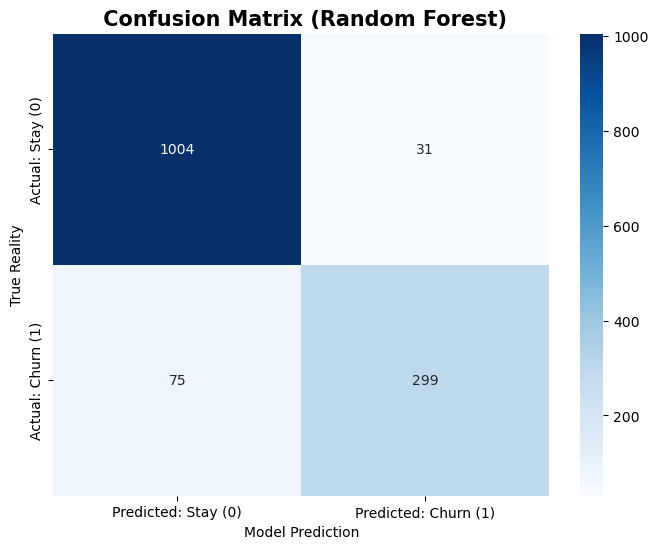

In [35]:

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted: Stay (0)', 'Predicted: Churn (1)'], 
            yticklabels=['Actual: Stay (0)', 'Actual: Churn (1)'])

plt.title(' Confusion Matrix (Random Forest)', fontsize=15, fontweight='bold')
plt.ylabel('True Reality')
plt.xlabel('Model Prediction')
plt.show()

C:\Users\Omar-PC\AppData\Local\Temp\ipykernel_25840\3735212255.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Impact', y='Feature', data=combined_impact,


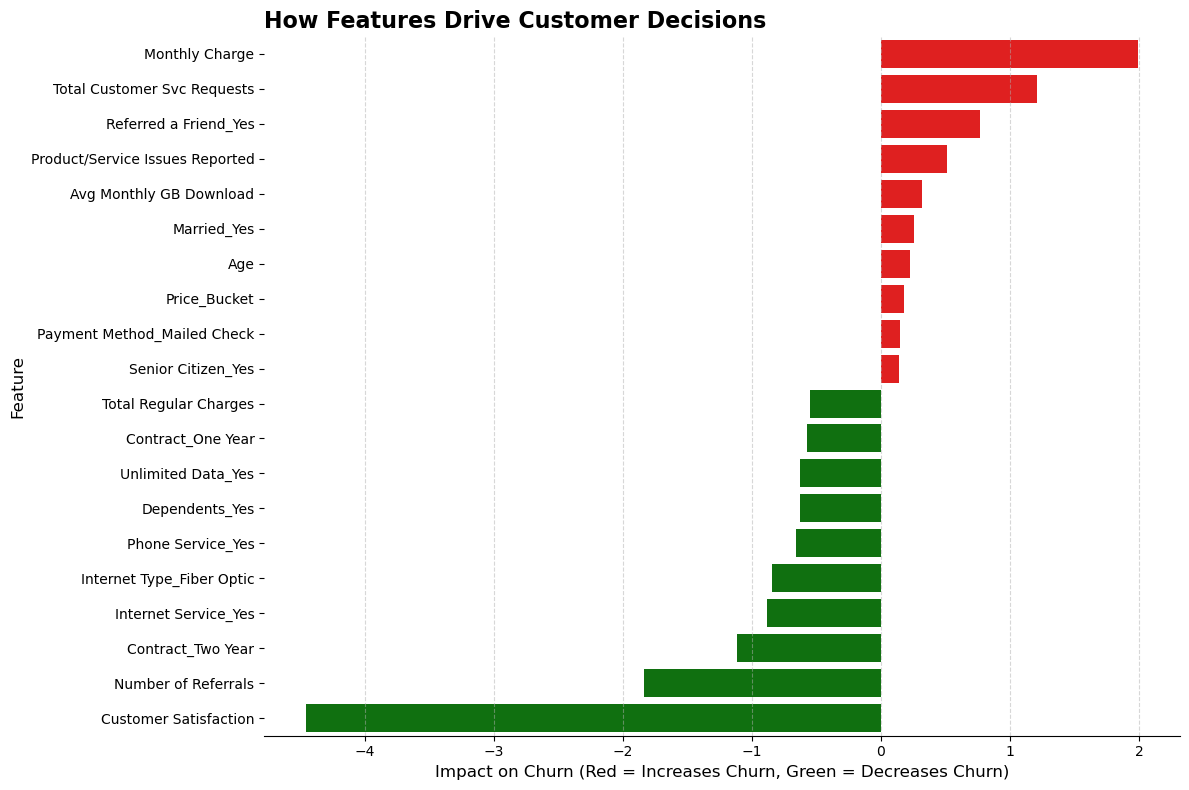

In [36]:
log_model_step = best_log_model.named_steps['logistic']

coefficients = log_model_step.coef_[0]
features = X_train.columns

coef_df = pd.DataFrame({'Feature': features, 'Impact': coefficients})
coef_df = coef_df.sort_values(by='Impact', ascending=False)

top_positive = coef_df.head(10) 
top_negative = coef_df.tail(10) 

combined_impact = pd.concat([top_positive, top_negative])

plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Impact', y='Feature', data=combined_impact, 
                 palette=['red' if x > 0 else 'green' for x in combined_impact['Impact']])

plt.title('How Features Drive Customer Decisions', fontsize=16, fontweight='bold',loc='left')
plt.xlabel('Impact on Churn (Red = Increases Churn, Green = Decreases Churn)', fontsize=12)
plt.ylabel('Feature', fontsize=12)

sns.despine(left=True, bottom=False)
ax.grid(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [37]:
print(df.columns)

Index(['Number of Referrals', 'Tenure in Months',
       'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download',
       'Monthly Charge', 'Total Regular Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges', 'Age',
       'Number of Dependents', 'Latitude', 'Longitude', 'Population',
       'Churn Value', 'CLTV', 'Total Customer Svc Requests',
       'Product/Service Issues Reported', 'Customer Satisfaction',
       'Price_Bucket', 'Population_2024', 'Referred a Friend_Yes',
       'Offer_Offer B', 'Offer_Offer C', 'Offer_Offer D', 'Offer_Offer E',
       'Phone Service_Yes', 'Multiple Lines_Yes', 'Internet Service_Yes',
       'Internet Type_DSL', 'Internet Type_Fiber Optic', 'Online Security_Yes',
       'Online Backup_Yes', 'Device Protection Plan_Yes',
       'Premium Tech Support_Yes', 'Streaming TV_Yes', 'Streaming Movies_Yes',
       'Streaming Music_Yes', 'Unlimited Data_Yes', 'Contract_One Year',
       'Contract_Two Year', 'Paperl

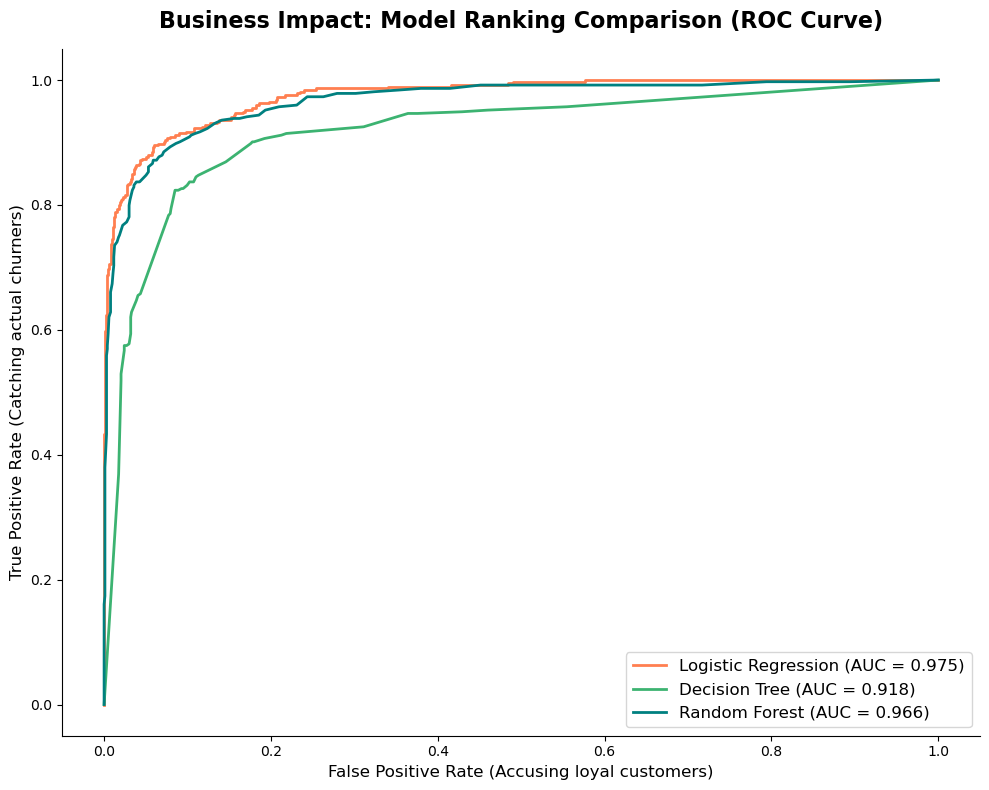

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns


y_prob_log = best_log_model.predict_proba(X_test)[:, 1]
y_prob_tree = best_tree_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

auc_log = roc_auc_score(y_test, y_prob_log)
auc_tree = roc_auc_score(y_test, y_prob_tree)
auc_rf = roc_auc_score(y_test, y_prob_rf)


fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)


plt.figure(figsize=(10, 8))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})', color='coral', lw=2)
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC = {auc_tree:.3f})', color='mediumseagreen', lw=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='teal', lw=2)


plt.title('Business Impact: Model Ranking Comparison (ROC Curve)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('False Positive Rate (Accusing loyal customers)', fontsize=12)
plt.ylabel('True Positive Rate (Catching actual churners)', fontsize=12)
plt.legend(loc="lower right", fontsize=12)

sns.despine()
plt.grid(False)

plt.tight_layout()
plt.show()

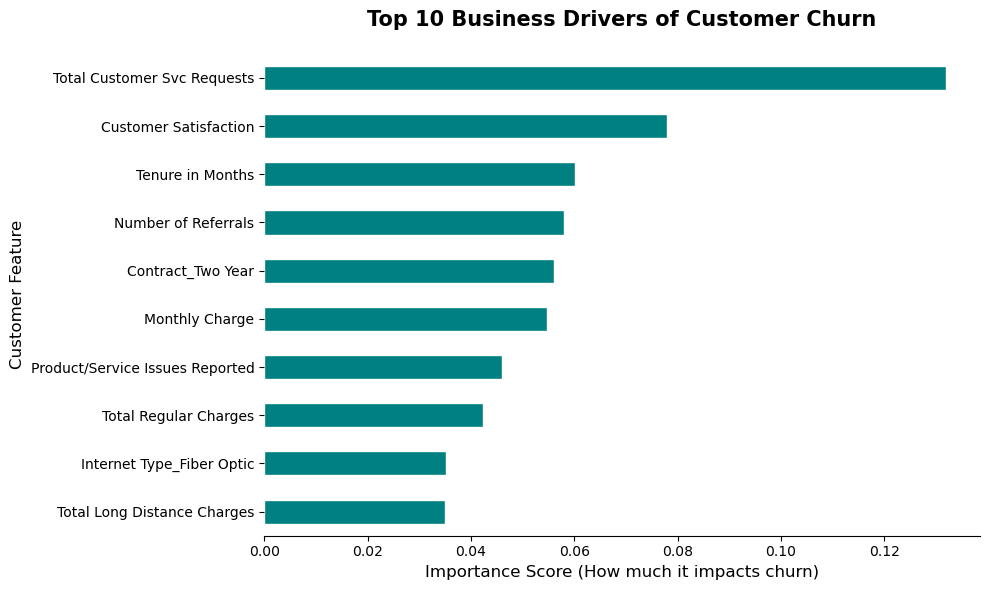

In [39]:
rf_classifier = rf_model.named_steps['rf']
importances = rf_classifier.feature_importances_
feat_importances = pd.Series(importances, index=X_train.columns)
plt.figure(figsize=(10, 6))
ax = feat_importances.nlargest(10).sort_values().plot(kind='barh', color='teal', edgecolor='white')
plt.title("Top 10 Business Drivers of Customer Churn", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Importance Score (How much it impacts churn)", fontsize=12)
plt.ylabel("Customer Feature", fontsize=12)
sns.despine(left=True, bottom=False) 
plt.tight_layout()
plt.show()